WARD COLUMNS:
['province', 'municipali', 'cat_b', 'wardno', 'district', 'districtco', 'date', 'wardid', 'wardlabel', 'geometry']

PHARM COLUMNS:
['raw_row_id', 'pharmacy_id', 'practice_num', 'practice_name', 'address', 'city', 'province', 'phone', 'query_string', 'http_status', 'api_status', 'place_id', 'matched_name', 'matched_address', 'lat', 'lng', 'types', 'raw_error', 'needs_review', 'filled_from_hospital']

Pharmacies outside all ward polygons: 0

Joined columns:
['raw_row_id', 'pharmacy_id', 'practice_num', 'practice_name', 'address', 'city', 'province_left', 'phone', 'query_string', 'http_status', 'api_status', 'place_id', 'matched_name', 'matched_address', 'lat', 'lng', 'types', 'raw_error', 'needs_review', 'filled_from_hospital', 'geometry', 'index_right', 'province_right', 'wardid', 'wardlabel', 'province_input_norm', 'province_ward_norm']
Province mismatches: 111

Gauteng wards: 529
Gauteng pharmacies (spatially assigned): 2802

KwaZulu-Natal wards: 901
KwaZulu-Natal pharma

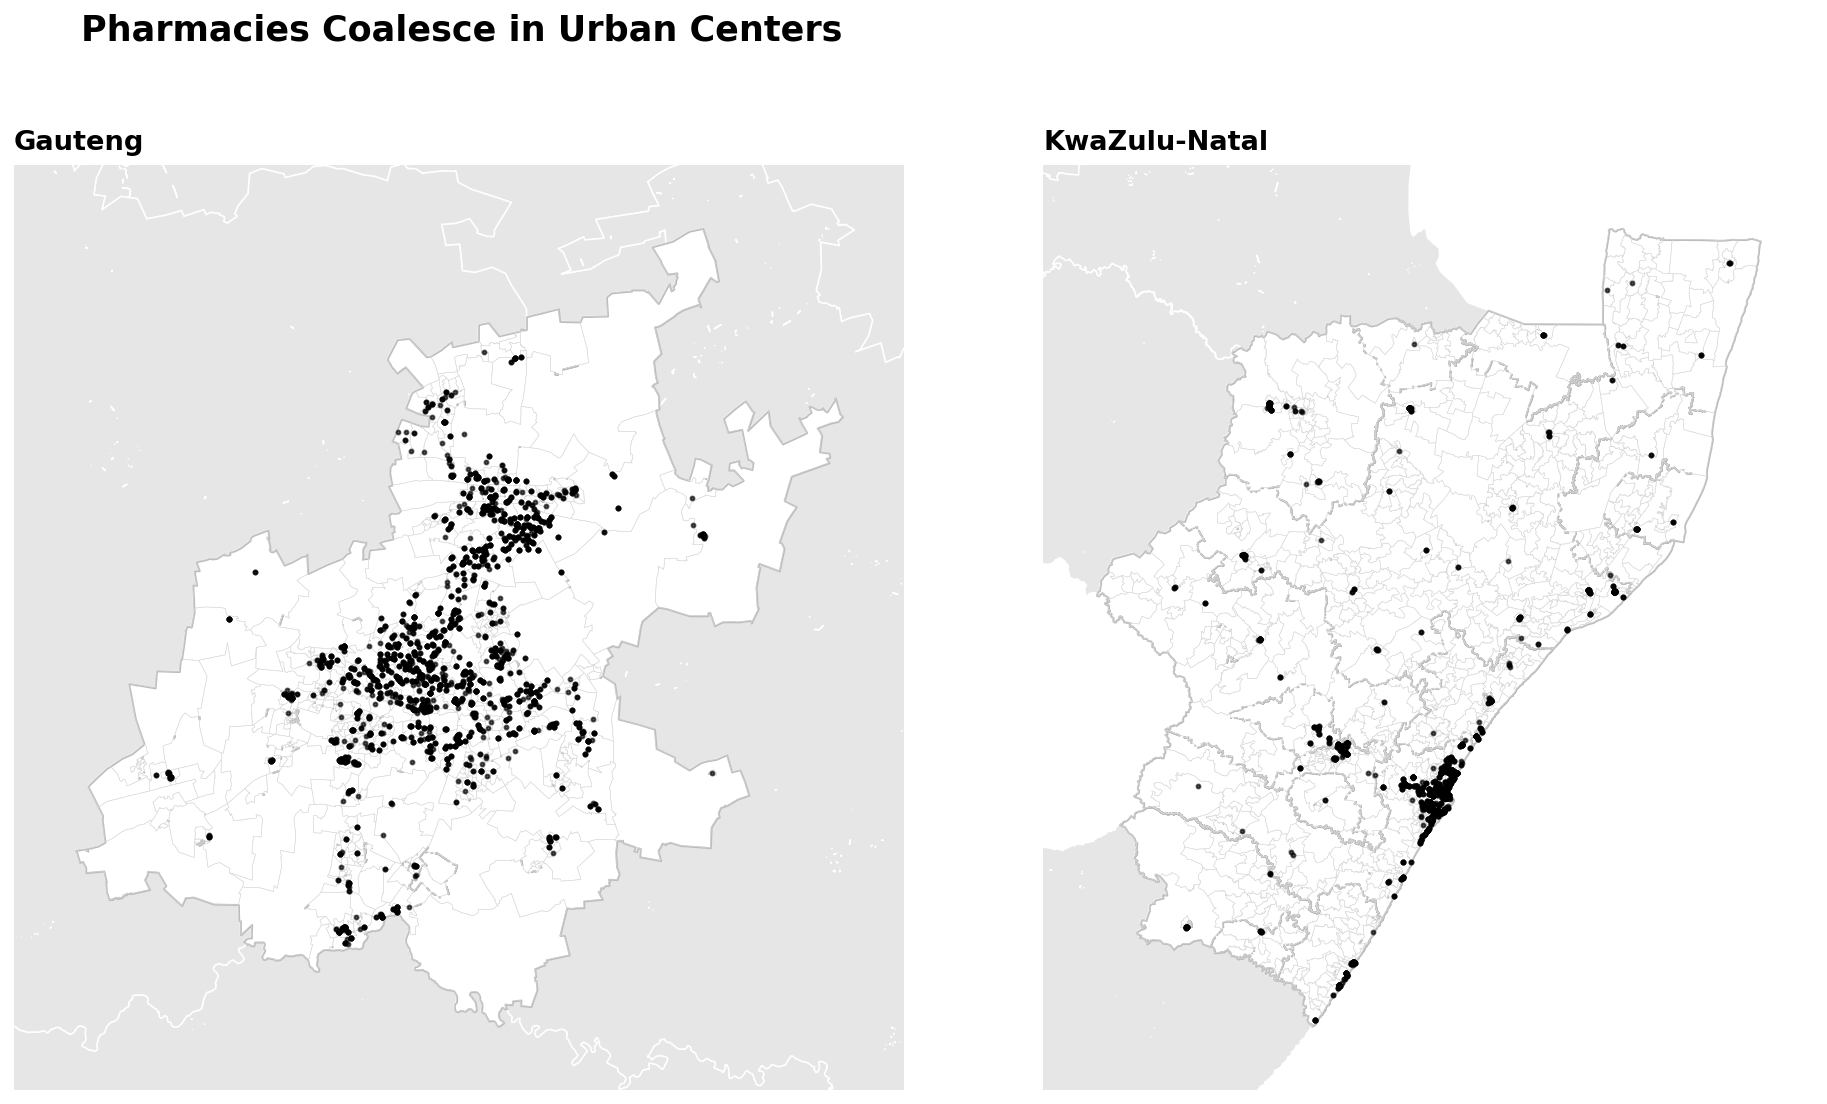

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

# --------------------------------------------------
# File paths
# --------------------------------------------------
wards_fp = r"C:\Users\jcahi\Box\DAIR_SA\Data Sets\Data from DAIR\2023_Census\SA_Wards2020.shp"
pharm_fp = r"C:\Users\jcahi\Box\DAIR_SA\Data Sets\Pharmacy Data\Cleaned Datasets\PHARMACIES_places_full_results.csv"

# --------------------------------------------------
# Load data
# --------------------------------------------------
wards = gpd.read_file(wards_fp)
pharm = pd.read_csv(pharm_fp)

# --------------------------------------------------
# Clean column names
# --------------------------------------------------
wards.columns = wards.columns.str.strip().str.lower()
pharm.columns = pharm.columns.str.strip().str.lower()

print("WARD COLUMNS:")
print(wards.columns.tolist())

print("\nPHARM COLUMNS:")
print(pharm.columns.tolist())

# --------------------------------------------------
# Clean coordinates
# --------------------------------------------------
pharm["lat"] = pd.to_numeric(pharm["lat"], errors="coerce")
pharm["lng"] = pd.to_numeric(pharm["lng"], errors="coerce")

# South Africa sanity bounds (approximate)
pharm = pharm[
    pharm["lat"].between(-36, -21) &
    pharm["lng"].between(16, 34)
].copy()

# Keep only successful geocodes with coords
pharm = pharm.dropna(subset=["lat", "lng"]).copy()

# optional: keep only likely successful matches
if "api_status" in pharm.columns:
    pharm = pharm[pharm["api_status"].astype(str).str.upper().eq("OK")].copy()

# --------------------------------------------------
# Build point GeoDataFrame
# --------------------------------------------------
pharm_gdf = gpd.GeoDataFrame(
    pharm,
    geometry=gpd.points_from_xy(pharm["lng"], pharm["lat"]),
    crs="EPSG:4326"
)

# Reproject to ward CRS if needed
if wards.crs != pharm_gdf.crs:
    pharm_gdf = pharm_gdf.to_crs(wards.crs)

# --------------------------------------------------
# Spatially assign each pharmacy to a ward
# --------------------------------------------------
# Keep only useful ward fields for join
wards_for_join = wards[["province", "wardid", "wardlabel", "geometry"]].copy()

# Use 'within' or 'intersects'
pharm_joined = gpd.sjoin(
    pharm_gdf,
    wards_for_join,
    how="left",
    predicate="within"
)

# --------------------------------------------------
# Diagnose unmatched points
# --------------------------------------------------
unmatched = pharm_joined[pharm_joined["wardid"].isna()].copy()
print(f"\nPharmacies outside all ward polygons: {len(unmatched)}")

# --------------------------------------------------
# Normalize province text for easier comparison
# --------------------------------------------------
def norm_province(x):
    if pd.isna(x):
        return None
    x = str(x).strip().lower()
    x = x.replace("-", " ")
    return " ".join(x.split())

pharm_joined["province_input_norm"] = pharm_joined["province_left"].map(norm_province) if "province_left" in pharm_joined.columns else pharm_joined["province"].map(norm_province)
pharm_joined["province_ward_norm"] = pharm_joined["province_right"].map(norm_province) if "province_right" in pharm_joined.columns else pharm_joined["province"].map(norm_province)

# If sjoin renamed columns differently, inspect:
print("\nJoined columns:")
print(pharm_joined.columns.tolist())

# --------------------------------------------------
# Province mismatch check
# --------------------------------------------------
# Adjust names if needed after inspecting columns
input_prov_col = "province_left" if "province_left" in pharm_joined.columns else "province"
ward_prov_col = "province_right" if "province_right" in pharm_joined.columns else "province"

pharm_joined["input_province_norm"] = pharm_joined[input_prov_col].map(norm_province)
pharm_joined["ward_province_norm"] = pharm_joined[ward_prov_col].map(norm_province)

mismatches = pharm_joined[
    pharm_joined["wardid"].notna() &
    (pharm_joined["input_province_norm"] != pharm_joined["ward_province_norm"])
].copy()

print(f"Province mismatches: {len(mismatches)}")

# --------------------------------------------------
# Build province subsets using SPATIAL province assignment
# --------------------------------------------------
gauteng_wards = wards[
    wards["province"].astype(str).str.contains("gauteng", case=False, na=False)
].copy()

kzn_wards = wards[
    wards["province"].astype(str).str.contains("kwazulu", case=False, na=False)
].copy()

gauteng_pts = pharm_joined[
    pharm_joined[ward_prov_col].astype(str).str.contains("gauteng", case=False, na=False)
].copy()

kzn_pts = pharm_joined[
    pharm_joined[ward_prov_col].astype(str).str.contains("kwazulu", case=False, na=False)
].copy()

print(f"\nGauteng wards: {len(gauteng_wards)}")
print(f"Gauteng pharmacies (spatially assigned): {len(gauteng_pts)}")

print(f"\nKwaZulu-Natal wards: {len(kzn_wards)}")
print(f"KwaZulu-Natal pharmacies (spatially assigned): {len(kzn_pts)}")

import matplotlib.pyplot as plt

# --------------------------------------------------
# Optional: subtle global styling for a cleaner print look
# --------------------------------------------------
plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 16
plt.rcParams["axes.titleweight"] = "bold"

# --------------------------------------------------
# Build a province-level backdrop so adjacent provinces appear light grey
# --------------------------------------------------
# Dissolve wards to provinces for a cleaner contextual background
province_outline = wards.dissolve(by="province", as_index=False)

# Make sure CRS matches
if province_outline.crs != pharm_joined.crs:
    province_outline = province_outline.to_crs(pharm_joined.crs)

# --------------------------------------------------
# Helper function for NYT-style province maps
# --------------------------------------------------
import matplotlib.pyplot as plt

# --------------------------------------------------
# Optional: subtle global styling
# --------------------------------------------------
plt.rcParams["figure.dpi"] = 140
plt.rcParams["font.size"] = 10
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.titleweight"] = "bold"

# --------------------------------------------------
# Build province-level backdrop
# --------------------------------------------------
province_outline = wards.dissolve(by="province", as_index=False)

if province_outline.crs != wards.crs:
    province_outline = province_outline.to_crs(wards.crs)

# --------------------------------------------------
# Clean NYT-style map function, no labels, no scale bar
# --------------------------------------------------
def plot_province_map(ax, province_name, province_wards, province_pts, all_provinces):
    # context provinces
    all_provinces.plot(
        ax=ax,
        color="#e6e6e6",
        edgecolor="white",
        linewidth=0.8,
        zorder=1
    )

    # focal province
    focal = all_provinces[
        all_provinces["province"].astype(str).str.contains(province_name, case=False, na=False)
    ]

    focal.plot(
        ax=ax,
        color="white",
        edgecolor="#bdbdbd",
        linewidth=1.0,
        zorder=2
    )

    # subtle ward boundaries
    province_wards.plot(
        ax=ax,
        color="none",
        edgecolor="#d9d9d9",
        linewidth=0.25,
        zorder=3
    )

    # pharmacy points
    province_pts.plot(
        ax=ax,
        color="black",
        markersize=4,
        alpha=0.65,
        zorder=4
    )

    # panel title
    pretty_name = "KwaZulu-Natal" if "kwazulu" in province_name.lower() else "Gauteng"
    ax.set_title(pretty_name, loc="left", pad=8)

    # framing
    xmin, ymin, xmax, ymax = province_wards.total_bounds
    xpad = (xmax - xmin) * 0.08
    ypad = (ymax - ymin) * 0.08
    ax.set_xlim(xmin - xpad, xmax + xpad)
    ax.set_ylim(ymin - ypad, ymax + ypad)

    ax.set_axis_off()

# --------------------------------------------------
# Draw the two maps
# --------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 8), facecolor="white")

plot_province_map(
    ax=axes[0],
    province_name="gauteng",
    province_wards=gauteng_wards,
    province_pts=gauteng_pts,
    all_provinces=province_outline
)

plot_province_map(
    ax=axes[1],
    province_name="kwazulu",
    province_wards=kzn_wards,
    province_pts=kzn_pts,
    all_provinces=province_outline
)

fig.suptitle(
    "Pharmacies Coalesce in Urban Centers",
    x=0.06, y=0.98, ha="left", fontsize=18, fontweight="bold"
)


plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

# --------------------------------------------------
# Export suspicious records
# --------------------------------------------------
suspect_cols = [
    c for c in [
        "raw_row_id", "pharmacy_id", "practice_name", "address", "city",
        input_prov_col, ward_prov_col, "matched_name", "matched_address",
        "lat", "lng", "types", "api_status", "raw_error", "needs_review"
    ] if c in pharm_joined.columns
]

unmatched[suspect_cols].to_csv(
    r"C:\Users\jcahi\Box\DAIR_SA\Data Sets\Pharmacy Data\Cleaned Datasets\pharmacies_outside_wards.csv",
    index=False
)

mismatches[suspect_cols].to_csv(
    r"C:\Users\jcahi\Box\DAIR_SA\Data Sets\Pharmacy Data\Cleaned Datasets\pharmacies_province_mismatches.csv",
    index=False
)

In [10]:
# --------------------------------------------------
# Identify Gauteng pharmacy points outside Gauteng ward boundaries
# --------------------------------------------------

# make sure ward polygons are a single combined geometry
gauteng_union = gauteng_wards.unary_union

# flag points that are not within Gauteng wards
gauteng_pts["inside_gauteng_wards"] = gauteng_pts.geometry.within(gauteng_union)

# extract outliers
gauteng_outliers = gauteng_pts[~gauteng_pts["inside_gauteng_wards"]].copy()

print(f"Outliers outside Gauteng wards: {len(gauteng_outliers)}")

# inspect key columns
cols_to_view = [
    c for c in [
        "pharmacy_id",
        "geocode_query",
        "geocode_formatted",
        "geocode_state",
        "geocode_city",
        "geocode_suburb",
        "geocode_road",
        "geocode_housenumber",
        "geocode_confidence",
        "geocode_lat",
        "geocode_lon"
    ] if c in gauteng_outliers.columns
]

print(gauteng_outliers[cols_to_view].head(20))

Outliers outside Gauteng wards: 0
Empty DataFrame
Columns: [pharmacy_id]
Index: []
